# Organizing charts + Data for filtering + trends in SFU over time:

The main goals of this notebook are primarily organization so that I can estimate the average fixed value for a single day with the ones that had all NaNs in the data:


In [1]:
#Imports:

from chime.calibration import load_Learmonth_data
import numpy as np
import matplotlib.pyplot as plt
import chime
import glob
from tqdm import trange
import os
import datetime
from scipy.interpolate import interp1d


df = load_Learmonth_data("/home/scratch/dbautist/CHIME_archive/learmonthData/L250609.SRD")

In [2]:
#Percentile for Solar Activity Probigation:
learmonth = "/home/scratch/dbautist/CHIME_archive/learmonthData/"
learmonth_files = glob.glob(f'{learmonth}/L25*SRD')
len(learmonth_files)

358

In [3]:
def daily_median(path, frequency):  #def in solar flux units
    
    '''Definition for mapping through each day in the wild card
    file path for the month(for example, January of 2026), maps out 
    and calculates the median for each day in that month in units 
    of Solar Flux Units'''

    df = load_Learmonth_data(path)
    med = np.nanmedian(df[frequency])
   
    return med

#print(column_NaN_count)

def Nan(path, frequency):
    df = load_Learmonth_data(path)
    count = df[frequency].isnull().sum()
    return count

In [4]:
#January

median_list = [] 
NaN_count = []

for i in trange(len(learmonth_files)):     
    output = daily_median(learmonth_files[i], '410')
    NaNs = Nan(learmonth_files[i], '410')
    median_list.append(output) 
    NaN_count.append(NaNs)
    #per = dif_percentile(NaNs, sec_in_months)
    

100%|██████████| 358/358 [59:30<00:00,  9.97s/it] 


In [5]:
#print statements for loop:

print(f'list for Jan in SFU:{median_list}')
print(f'outliers for this month: {NaN_count}')


list for Jan in SFU:[42.0, 48.0, 43.0, 46.0, 43.0, 42.0, 41.0, 42.0, 42.0, 43.0, 49.0, 46.0, 44.0, 46.0, 45.0, 46.0, 53.0, 1.0, 71.0, 44.0, 62.0, 53.0, 48.0, 45.0, 44.0, 42.0, 40.0, 41.0, 40.0, 41.0, 42.0, 47.0, 42.0, 40.0, 43.0, 42.0, 46.0, 45.0, 44.0, 42.0, 40.0, 42.0, 44.0, 42.0, 44.0, 44.0, 46.0, 42.0, 43.0, 48.0, 45.0, 40.0, 43.0, 45.0, 42.0, 42.0, 40.0, 38.0, 38.0, 38.0, 39.0, 43.0, 43.0, 40.0, 41.0, 41.0, 42.0, 40.0, 43.0, 41.0, 42.0, 45.0, 44.0, 48.0, 45.0, 40.0, 40.0, 41.0, 43.0, 39.0, 42.0, 29.0, 43.0, 40.0, 41.0, 42.0, 38.0, 37.0, 42.0, 43.0, 45.0, 49.0, 50.0, 46.0, 46.0, 40.0, 40.0, 41.0, 44.0, 44.0, 46.0, 45.0, 50.0, 50.0, 47.0, 46.0, 42.0, 41.0, 38.0, 44.0, 40.0, 40.0, 39.0, 34.0, 42.0, 39.0, 44.0, 42.0, 41.0, 44.0, 46.0, 43.0, 45.0, 40.0, 42.0, 42.0, 35.0, 41.0, 41.0, 40.0, 39.0, 40.0, 39.0, 35.0, 39.0, 37.0, 39.0, 39.0, 38.0, 37.0, 28.0, 35.0, 38.0, 39.0, 47.0, 48.0, 41.0, 43.0, 49.0, 43.0, 42.0, 31.0, 39.0, 37.0, 40.0, 38.0, 37.0, 35.0, 37.0, 36.0, 39.0, 41.0, 44.0, 44

In [6]:
print(f'nan:{sum(NaN_count)}')

nan:15473270


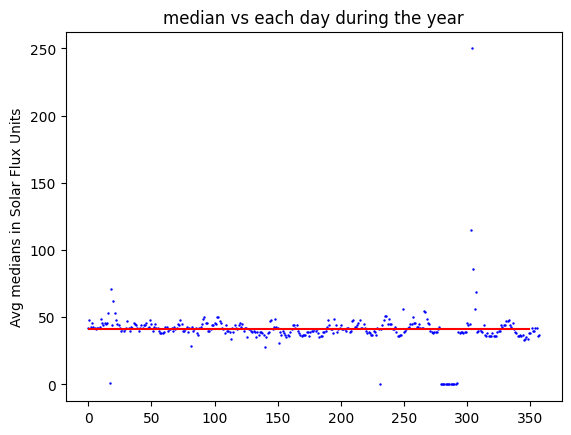

In [7]:
#scatter plot for data over time(raw scatter plot not the neat thing yet):


Days = np.arange(0, len(median_list))

#first plot(in SFU):
plt.scatter(Days, median_list, color='blue', label='SFU', s=3, linewidths=0)
plt.title(f"median vs each day during the year")
plt.ylabel("Avg medians in Solar Flux Units")
monthly_median = np.nanmedian(median_list)
plt.hlines(monthly_median, xmin=0, xmax=350, color='red')


# Monthly list:


In [8]:
#Organizing by months + seeing trends:

months = ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']
month_dict = {}

for month in months:
    string = ""
    month_dict[month] = glob.glob(f'{learmonth}/L25{month}*SRD')
    
    
day_path = month_dict['12'][0]
df_list = load_Learmonth_data(day_path)

In [13]:
print(month_dict['10'])


for i in trange(month_dict['10']):     
    output = daily_median(learmonth_files[i], '410')
    NaNs = Nan(learmonth_files[i], '410')
    median_list.append(output) 
    NaN_count.append(NaNs)

['/home/scratch/dbautist/CHIME_archive/learmonthData/L251001.SRD', '/home/scratch/dbautist/CHIME_archive/learmonthData/L251002.SRD', '/home/scratch/dbautist/CHIME_archive/learmonthData/L251003.SRD', '/home/scratch/dbautist/CHIME_archive/learmonthData/L251004.SRD', '/home/scratch/dbautist/CHIME_archive/learmonthData/L251005.SRD', '/home/scratch/dbautist/CHIME_archive/learmonthData/L251006.SRD', '/home/scratch/dbautist/CHIME_archive/learmonthData/L251007.SRD', '/home/scratch/dbautist/CHIME_archive/learmonthData/L251008.SRD', '/home/scratch/dbautist/CHIME_archive/learmonthData/L251009.SRD', '/home/scratch/dbautist/CHIME_archive/learmonthData/L251010.SRD', '/home/scratch/dbautist/CHIME_archive/learmonthData/L251011.SRD', '/home/scratch/dbautist/CHIME_archive/learmonthData/L251012.SRD', '/home/scratch/dbautist/CHIME_archive/learmonthData/L251013.SRD', '/home/scratch/dbautist/CHIME_archive/learmonthData/L251014.SRD', '/home/scratch/dbautist/CHIME_archive/learmonthData/L251015.SRD', '/home/sc

TypeError: 'list' object cannot be interpreted as an integer

# Filtering good and bad days of data out:

In [27]:
#filtering:

#Testing specifically with May 2025 to see if the filtering works

Days = np.arange(0, len(median_list))

def filtering(df):
    median = (not np.isnan(np.nanmedian(df['410']))) and np.nanmedian(df['410']) != 1 and np.nanmedian(df['410']) > 0
    result = median
    return result
            
good_data = []
bad_data = []
good_date = []
bad_date = []

for month in months:
    for i in trange(len(month_dict[month])):
        path = month_dict[month][i]
        df = load_Learmonth_data(path)
        
        if filtering(df):
            good_data.append(path)
        else:
            bad_data.append(path)
            
for date in good_data:
    base = os.path.basename(date)[3:7]
    num_date = int(base)
    good_date.append(num_date)
    
print(good_date)

100%|██████████| 31/31 [02:34<00:00,  4.99s/it]

[101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513, 514, 515, 516, 517, 518, 519, 520, 521, 522, 523, 524, 525, 526, 527, 528, 529, 530, 531, 601, 602, 603, 604, 605, 606, 607, 608, 609, 610, 611, 612, 613, 614, 615, 616, 617, 618, 619, 620, 621, 622, 623, 624, 625, 626, 627, 628, 629, 630, 701, 702, 703, 704, 705, 706, 707, 708, 709, 710, 711, 712, 713, 714, 715, 716, 717, 718, 721, 722, 723, 724,

In [28]:
len(good_date)

342

In [ ]:

for nodate in bad_data:
    nobase = os.path.basename(nodate)[3:7]
    no_num_date = int(nobase)
    bad_date.append(no_num_date)
    


In [26]:
len(some_date)

0

In [12]:
#Importing in a range that makes sense for flux:

#good data plot:

flux_410 = []

for i in trange(len(good_data)):
    p = good_data[i]
    df = load_Learmonth_data(p)
    flux_410.append(np.nanmedian(df['410']))

100%|██████████| 342/342 [27:52<00:00,  4.89s/it]


In [32]:
from datetime import datetime


good_datetime = []

bad_datetimes = []

for good in good_data:
    file = os.path.basename(good)
    new_var = datetime.strptime(file, "L%y%m%d.SRD")
    good_datetime.append(new_var)
    
for bad in bad_data:
    fileb = os.path.basename(bad)
    bad_var = datetime.strptime(fileb, "L%y%m%d.SRD")
    bad_datetimes.append(bad_var)

In [33]:
good_days = np.arange(0, len(good_data))
len(good_days)
bad_days =  np.arange(0, len(bad_data))
len(bad_days)
print(bad_days)

type(bad_days)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


numpy.ndarray

342

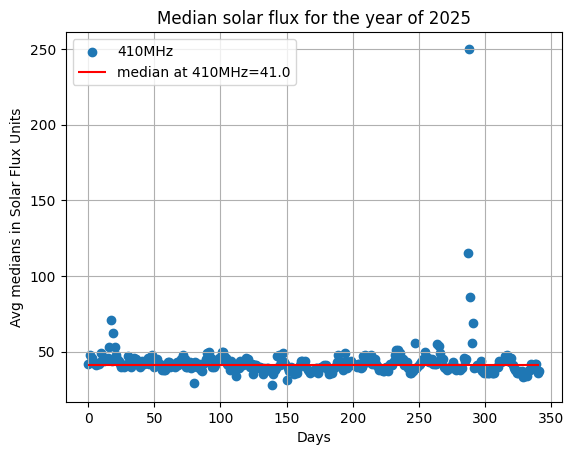

In [41]:
#plotting the organized/good product and trends in the SFU with mostly
#filtered Data:

plt.figure()
plt.scatter(good_days, flux_410, label='410MHz')
plt.legend()
plt.title("Median solar flux for the year of 2025")
plt.ylabel("Avg medians in Solar Flux Units")
plt.xlabel("Days")
plt.grid()
plt.hlines(np.median(flux_410), min(good_days), max(good_days), color='red', label=f'median at 410MHz={np.median(flux_410)}')
plt.legend() 
len(flux_410)

ValueError: A value (1.0) in x_new is below the interpolation range's minimum value (101).

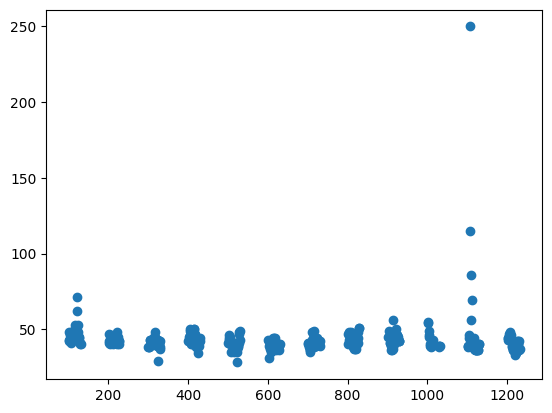

In [42]:
#Estimating for the median value for days that do not have data points:
from scipy import interpolate

from scipy.interpolate import interp1d

#plot in units of Janskys:
f = interpolate.interp1d((good_date), (flux_410))

ynew = f(good_date)
yfilled = f(bad_date)

plt.figure()
plt.scatter(good_date, flux_410, label='410Mhz')
plt.scatter(bad_date, yfilled, color='red', label='interpoliated values')
m = np.linspace(1, 31)
plt.plot(m, f(m), color='lightgreen', label='fit')


plt.legend()
plt.title(f"Median solar flux for the month of {month}")
plt.ylabel("flux in Janskys")

plt.grid()
#plt.hlines(np.median(flux_410), min(good_data), max(good_data))
plt.legend()


In [43]:
print(good_date)

[101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513, 514, 515, 516, 517, 518, 519, 520, 521, 522, 523, 524, 525, 526, 527, 528, 529, 530, 531, 601, 602, 603, 604, 605, 606, 607, 608, 609, 610, 611, 612, 613, 614, 615, 616, 617, 618, 619, 620, 621, 622, 623, 624, 625, 626, 627, 628, 629, 630, 701, 702, 703, 704, 705, 706, 707, 708, 709, 710, 711, 712, 713, 714, 715, 716, 717, 718, 721, 722, 723, 724,

In [39]:
len(flux_410)

342